# COMP 6940: Big Data and Data Visualization

### Project: Airline Delay Analysis and Performance Optimization  
#### Dataset: Carrier On-Time Performance Dataset  

## **Notebook:** 02 — Exploratory Data Analysis  

**Objective:** 

This notebook explores the cleaned flight dataset to identify patterns, trends, and relationships in airline delays. The analysis focuses on temporal patterns, airline and airport performance, and the underlying factors contributing to arrival delays. The insights derived from this stage will guide further analysis and support data-driven conclusions regarding the delay behaviour.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

In [2]:
df = pd.read_csv("cleaned_flight_data.csv", low_memory=False)
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

if "IsArrivalDelayed" not in df.columns:
    df["IsArrivalDelayed"] = df["ArrDelay"] > 0

oper = df[df["Cancelled"] == 0].copy()
oper["ArrDelay"] = pd.to_numeric(oper["ArrDelay"], errors="coerce")
oper["DepDelay"] = pd.to_numeric(oper["DepDelay"], errors="coerce")

## 1. Dataset Size and Scope

Before conducting further analysis, it is important to understand the scale of the dataset. Given the large volume of flight records, even small percentages of delays can correspond to a significant number of affected flights.

This highlights the importance of analyzing both the proportion and absolute count of delays, as large-scale datasets amplify the real-world impact of operational inefficiencies.

In [3]:
n = len(df)
n_op = len(oper)
d0, d1 = df["FlightDate"].min(), df["FlightDate"].max()
print(f"Rows: {n:,}")
print(f"Non-cancelled rows: {n_op:,} ({100 * n_op / n:.1f}%)")
print(f"FlightDate range: {d0.date()} — {d1.date()}")

Rows: 2,000,000
Non-cancelled rows: 1,963,538 (98.2%)
FlightDate range: 1987-10-01 — 2020-03-31


**Insight:** 

The analysis subset keeps only completed flights so arrival and departure delay minutes are defined; cancelled rows are retained in the file for completeness but excluded from delay-only charts.

---

## 2. How Common are Delays?

### Arrival Delay Prevalence

This section examines the proportion of flights that arrive on time or early compared to those that experience arrival delays. Establishing this baseline provides an initial understanding of how common delays are within airline operations.

Share of flights with ArrDelay > 0: 43.8%


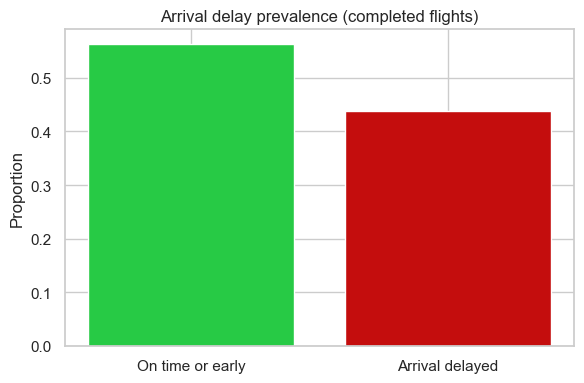

In [27]:
rate = oper["IsArrivalDelayed"].mean()
print(f"Share of flights with ArrDelay > 0: {100 * rate:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["On time or early", "Arrival delayed"], [1 - rate, rate], color=["#27ca45", "#C40D0D"])
ax.set_ylabel("Proportion")
ax.set_title("Arrival delay prevalence (completed flights)")
plt.tight_layout()
plt.show()

**Insight:**

The results show that although a slightly larger proportion of flights arrive on time or early, a substantial percentage of flights still experience delays. This indicates that delays are not isolated events but occur regularly within the system.

Given the size of the dataset, even this proportion represents a large number of affected flights. This highlights the importance of identifying the key drivers of delays, as small improvements could have significant real-world impact.

---

## 3. When do delays occur?

### 3.1 Monthly Trends in Arrival Delays

**Monthly Average Arrival Delay and Delay Volume**

This section explores temporal patterns in arrival delays by analyzing both the average delay duration per month and the total number of delayed flights. Together, these two perspectives provide a more comprehensive understanding of delay behavior.

The average delay reflects the severity of delays when they occur.
The count of delayed flights reflects the frequency or volume of disruptions.

By examining these metrics jointly, we can distinguish between periods with frequent minor delays and periods characterized by fewer but more severe disruptions. This dual analysis is essential for identifying seasonal patterns, operational bottlenecks, and potential capacity constraints within the aviation system.

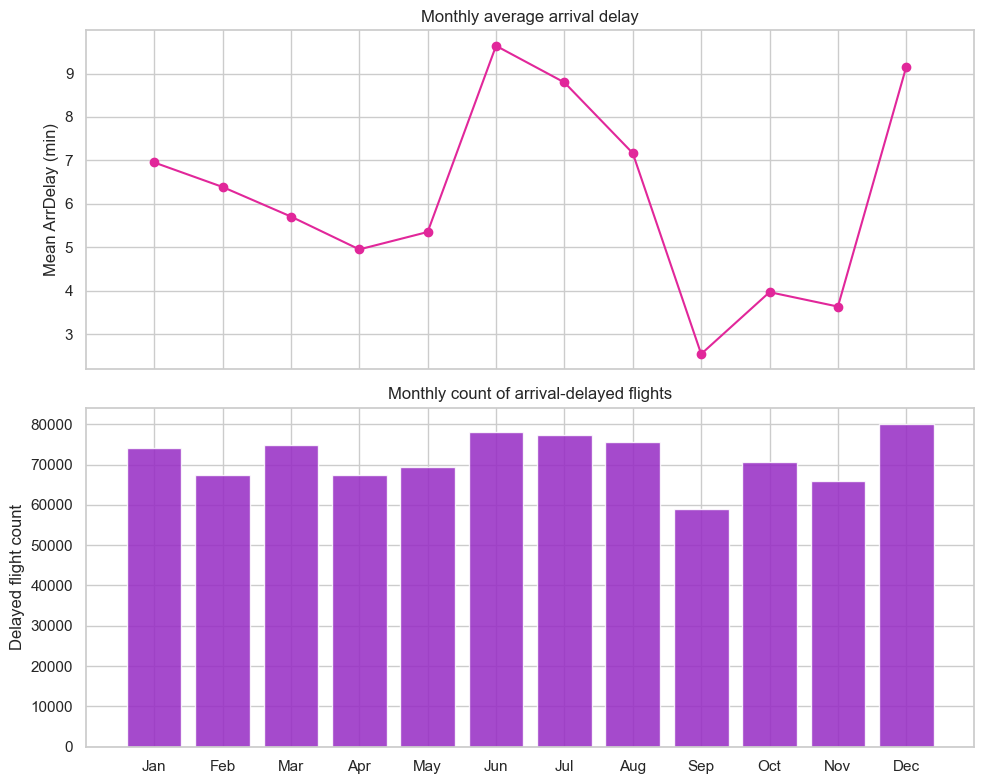

In [20]:
monthly_avg = oper.groupby("Month")["ArrDelay"].mean()
monthly_delayed = oper.groupby("Month")["IsArrivalDelayed"].sum()

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[0].plot(monthly_avg.index, monthly_avg.values, marker="o", color="#e1279a")
axes[0].set_ylabel("Mean ArrDelay (min)")
axes[0].set_title("Monthly average arrival delay")
axes[1].bar(monthly_delayed.index, monthly_delayed.values, color="#962ac4", alpha=0.85)
axes[1].set_ylabel("Delayed flight count")
axes[1].set_title("Monthly count of arrival-delayed flights")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months)
plt.tight_layout()
plt.show()

**Insight:** 

The analysis reveals clear seasonal variability in both the magnitude and frequency of arrival delays:

Mid-year (June–July) shows the highest average delays, indicating more severe disruptions during peak travel periods. This may be driven by increased passenger demand, air traffic congestion, or weather-related factors.
September exhibits a sharp drop in average delay, suggesting improved operational efficiency or reduced traffic volume after the summer peak.
December shows a notable increase again, likely reflecting holiday travel surges and associated congestion.

In terms of delay counts, months such as June, July, and December also show higher volumes of delayed flights, reinforcing the idea that peak holiday travel periods strain the system both in frequency and severity.

Overall, the results confirm that delays are not uniformly distributed throughout the year but are strongly driven by seasonal demand fluctuations and capacity constraints. Periods of high travel demand not only increase the number of delayed flights but also amplify the severity of those delays, reinforcing the impact of congestion on system performance.

---

### 3.2 Average Arrival Delay by Day of Week

This analysis evaluates how arrival delays vary across different days of the week. By aggregating mean delay durations by weekday, we can identify whether certain days consistently experience higher levels of disruption.

This perspective is particularly useful for understanding how operational load, business travel patterns, and scheduling intensity influence system performance throughout the week.

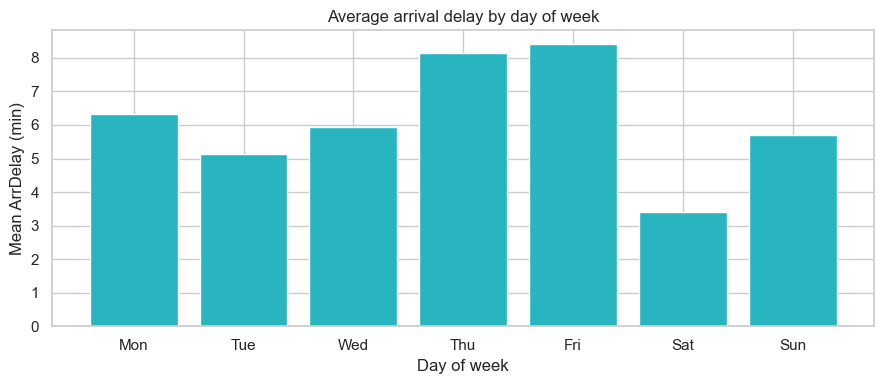

In [19]:
dow_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
by_dow = oper.groupby("DayOfWeek")["ArrDelay"].mean().reindex(range(1, 8))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 8), by_dow.values, color="#28b5c0")
ax.set_xticks(range(1, 8))
ax.set_xticklabels([dow_map[i] for i in range(1, 8)])
ax.set_xlabel("Day of week")
ax.set_ylabel("Mean ArrDelay (min)")
ax.set_title("Average arrival delay by day of week")
plt.tight_layout()
plt.show()

**Insight:** 

The results show a clear weekday effect in arrival delays:

- Thursday and Friday exhibit the highest average delays, suggesting increased congestion toward the end of the workweek.
- Saturday has the lowest delays, indicating reduced traffic volume and less operational pressure.
- Early-week days (Monday–Wednesday) show moderate delay levels, reflecting more balanced demand.

This pattern aligns with expected travel behavior, where business and leisure travel intensifies later in the week. The findings suggest that operational strain builds up over the week, leading to more frequent or severe delays by Thursday and Friday.

---

### 3.3 Average Arrival Delay by Hour of Day

This section examines how arrival delays vary throughout the day based on scheduled departure hour. Temporal patterns at the hourly level are critical for identifying congestion periods, delay propagation effects, and scheduling inefficiencies.

By analyzing delays across a 24-hour cycle, we can observe how early-day conditions influence later operations and whether delays accumulate over time.

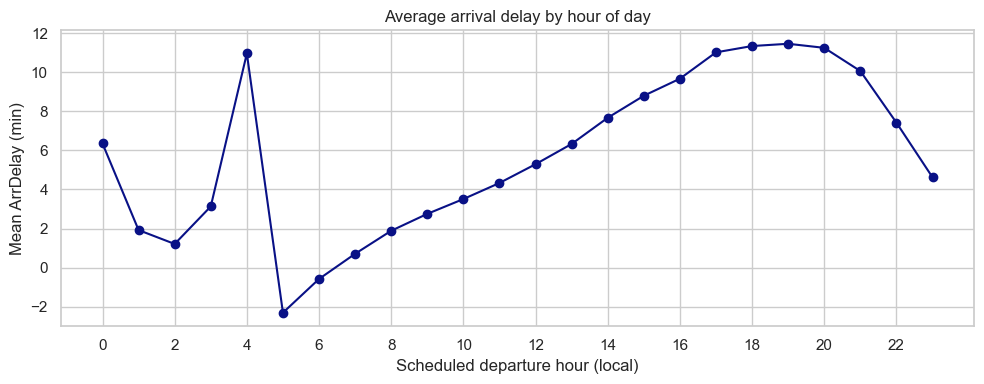

In [26]:
h = oper.dropna(subset=["DepHour"])
by_hour = h.groupby("DepHour")["ArrDelay"].mean().reindex(range(24))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_hour.index, by_hour.values, marker="o", color="#091186")
ax.set_xlabel("Scheduled departure hour (local)")
ax.set_ylabel("Mean ArrDelay (min)")
ax.set_title("Average arrival delay by hour of day")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

**Insight:** 

A strong time-of-day effect is observed:

- Early morning hours (around 5–7 AM) show the lowest delays, with some flights even arriving early (negative delay).
- Delays steadily increase throughout the day, peaking in the late afternoon and evening (5–8 PM).
- After peak hours, delays begin to decline again late at night.

This pattern provides strong evidence of delay propagation, where early disruptions accumulate and cascade throughout the day. Flights scheduled later are increasingly exposed to upstream delays, congestion, and resource limitations.

From an operational perspective, this suggests that improving early-day punctuality could have a compounding positive effect on overall system performance, reducing delays across the entire daily schedule.

---

## 4. Which Airlines and Airports are Most Affected?

Top 10 by mean arrival delay (minimum 500 flights per airline / origin to reduce noise).

**Top Airlines and Origin Airports by Mean Arrival Delay**

This section compares average arrival delays across airlines and origin airports. By identifying the entities with the highest mean delays, we can uncover structural inefficiencies, operational challenges, or environmental factors that contribute to poor performance.

This analysis provides insight into whether delays are driven more by carrier-level practices or airport-level constraints.

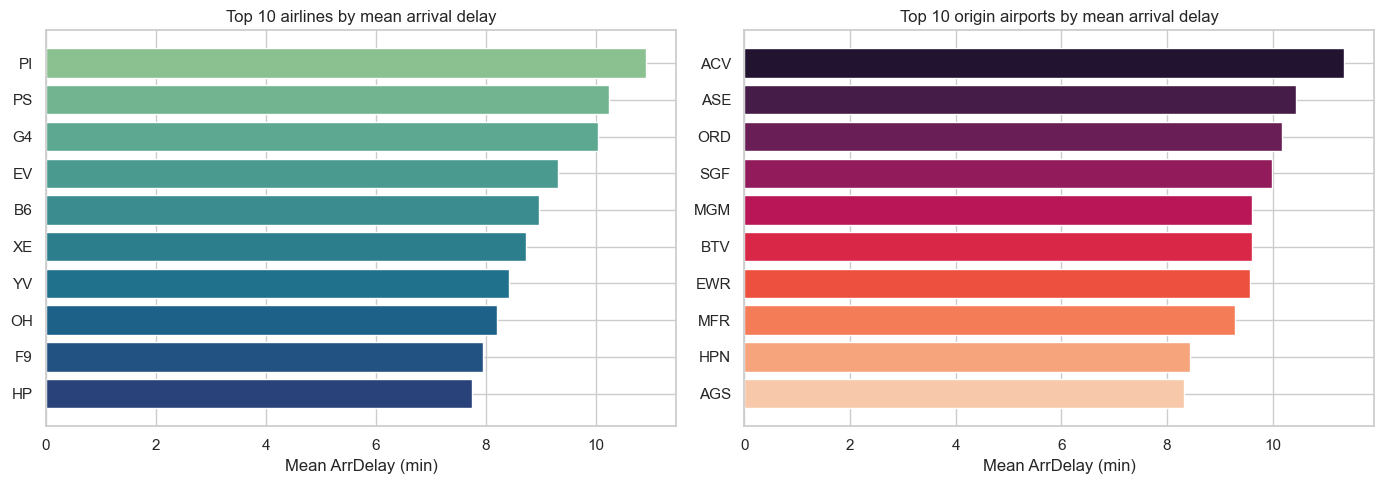

In [16]:
def top_by_mean_delay(gb_col, min_n=500, top_k=10):
    g = oper.groupby(gb_col).agg(n=("ArrDelay", "size"), mean_ad=("ArrDelay", "mean"))
    g = g[g["n"] >= min_n].sort_values("mean_ad", ascending=False).head(top_k)
    return g


top_airlines = top_by_mean_delay("Reporting_Airline")
top_airports = top_by_mean_delay("Origin")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_airlines.index.astype(str), top_airlines["mean_ad"], color=sns.color_palette("crest", len(top_airlines)))
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean ArrDelay (min)")
axes[0].set_title("Top 10 airlines by mean arrival delay")
axes[1].barh(top_airports.index.astype(str), top_airports["mean_ad"], color=sns.color_palette("rocket", len(top_airports)))
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean ArrDelay (min)")
axes[1].set_title("Top 10 origin airports by mean arrival delay")
plt.tight_layout()
plt.show()

**Insight:** 

The analysis reveals clear performance differences across both airlines and origin airports:

- The worst-performing airlines exhibit mean arrival delays exceeding 10 minutes, while better-performing carriers are closer to 7–8 minutes, indicating a meaningful operational gap.
- Similarly, certain origin airports consistently show elevated delay levels, suggesting the presence of localized congestion, infrastructure limitations, or air traffic control constraints.

These findings indicate that delays are not randomly distributed but are influenced by systematic, entity-specific factors. In particular, the variation across airlines suggests differences in scheduling efficiency, turnaround management, and operational resilience. Meanwhile, airport-level disparities point to external constraints that may impact all carriers operating within those locations.

Overall, this highlights that improving performance requires targeted interventions at both the airline and airport levels, rather than relying solely on system-wide policies.

---

## 5. Arrival VS Departure Delay

Random sample for readability on large \(n\).

**Relationship Between Departure and Arrival Delays**

This section investigates the relationship between departure delays and arrival delays using a scatter plot. Understanding this relationship is essential for determining whether delays originate at departure or are primarily accumulated during flight.

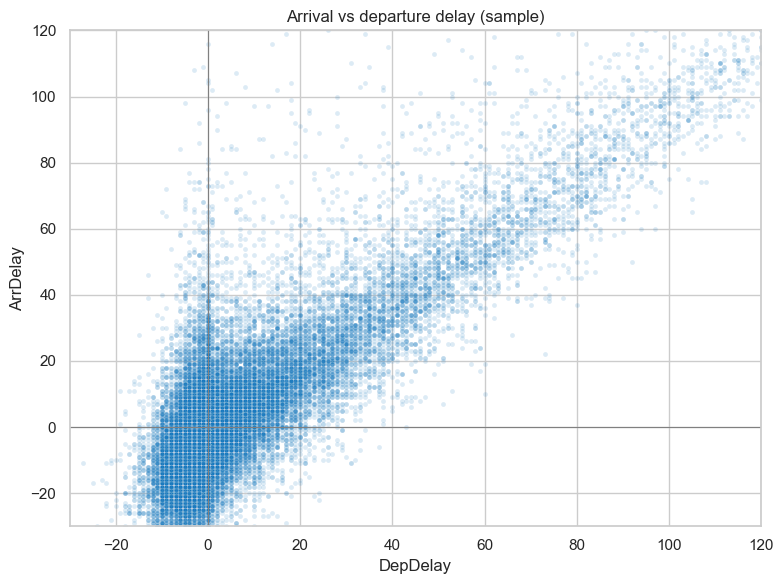

In [25]:
sample_n = min(50_000, len(oper))
sam = oper.sample(sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=sam, x="DepDelay", y="ArrDelay", alpha=0.15, s=12, color="#1679bf", ax=ax)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlim(-30, 120)
ax.set_ylim(-30, 120)
ax.set_title("Arrival vs departure delay (sample)")
plt.tight_layout()
plt.show()

**Insight:** 

A strong positive linear relationship is evident between departure and arrival delays:

- Flights that depart late tend to also arrive late.
- The clustering along a diagonal trend indicates high dependency between the two variables.

However, there is some spread around the trend line, suggesting that:

- Certain flights recover time during transit
- Others experience additional delays mid-flight or during arrival

Overall, departure delay appears to be a primary driver of arrival delay, reinforcing the importance of minimizing delays at the origin stage.

---

## 6. Correlation Heatmap (Delay-Related Numerics)

Subset of columns most tied to delay minutes and causes.

**Correlation Analysis of Delay-Related Features**

This section presents a correlation matrix of key delay-related variables, including arrival delay, departure delay, and specific delay causes (e.g., carrier, weather, NAS). The objective is to quantify the strength and direction of relationships between these variables.

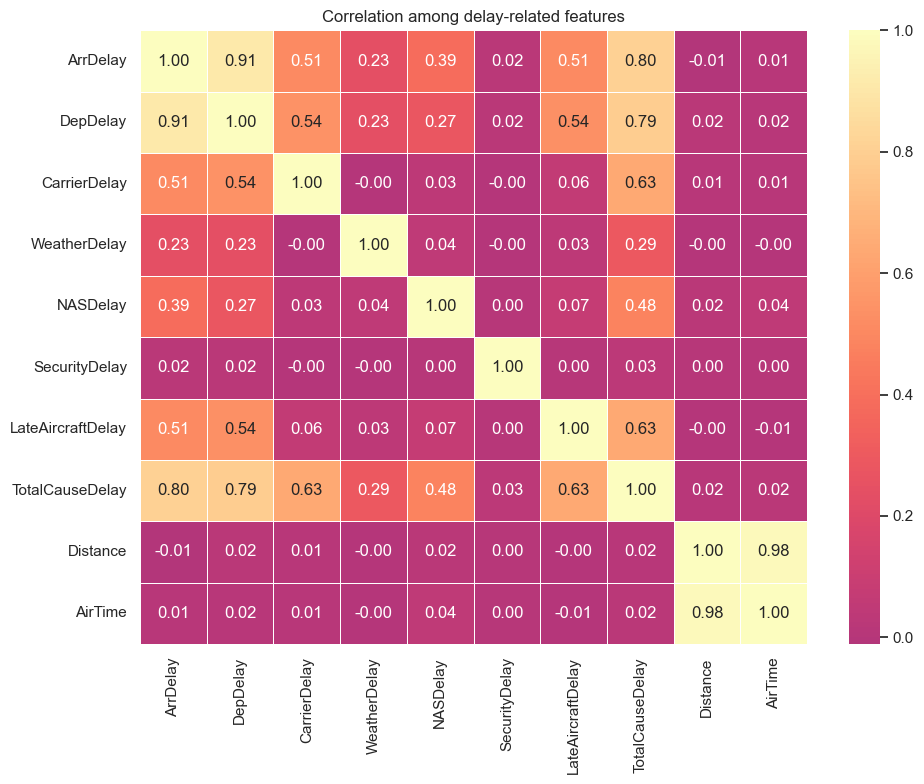

In [13]:
corr_cols = [
    c
    for c in [
        "ArrDelay",
        "DepDelay",
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay",
        "TotalCauseDelay",
        "Distance",
        "AirTime",
    ]
    if c in oper.columns
]
cm = oper[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="magma", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation among delay-related features")
plt.tight_layout()
plt.show()

**Insight:** 

Key observations from the correlation matrix include:

- Arrival delay and departure delay are highly correlated (~0.91), confirming that departure delays strongly influence arrival outcomes.
- TotalCauseDelay shows strong correlation with both arrival and departure delays (~0.80), indicating that aggregated delay causes are major contributors.
- CarrierDelay and LateAircraftDelay also show moderate correlations, suggesting operational inefficiencies and aircraft turnaround issues play a role.
- Weather and Security delays exhibit weak correlations, implying they are less frequent or more isolated in impact.
- Distance and AirTime are highly correlated (~0.98) but show negligible correlation with delays, indicating that flight length itself is not a primary driver of delay.

Taken together, these relationships reinforce that arrival delays are primarily driven by operational and systemic factors, particularly those originating at departure and during aircraft turnaround. External factors such as distance play a minimal role, highlighting that improvements in operational efficiency are likely to yield the greatest reductions in delay.

---

### Overall Insights and Key Findings

This exploratory analysis provides a comprehensive understanding of the patterns and drivers of flight delays across multiple dimensions, including time, operational factors, and system-level characteristics.

Several key insights emerge:

- Delays are widespread, with a substantial proportion of flights arriving late, indicating that delays are a systemic issue rather than isolated events.
- Temporal effects are highly significant, with delays increasing throughout the day and peaking in the evening, demonstrating clear evidence of delay propagation.
- Seasonal patterns are evident, as peak travel months (e.g., mid-year and December) exhibit both higher delay severity and higher delay frequency, suggesting capacity constraints during high-demand periods.
- Operational factors dominate, as shown by strong correlations between arrival delays, departure delays, and total delay causes, while variables such as distance have negligible impact.
- Entity-level variation exists, with certain airlines and airports consistently exhibiting higher delays, indicating structural inefficiencies within specific parts of the network.

Overall, these findings highlight that flight delays are primarily driven by operational congestion and scheduling inefficiencies, rather than structural characteristics of flights themselves. This suggests that improvements in scheduling, resource allocation, and delay management strategies could significantly enhance overall system performance.